<a href="https://colab.research.google.com/github/Luke-687/Simulating-Chemotaxis--Q-learning-and-Heuristic-/blob/main/Heuristic%20Approach/Model-Data-and-Visuals/Sample-10-Worst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Sample the worst trajectoris to pick up on a possible bug (worst 10 trajectories of a 1000 group sample for good (gamma:0.6, alpha:0.6) and poor (gamma:0.1, alpha:0.1) conditions

In [ ]:
import math
import random
import matplotlib.pyplot as plt

In [ ]:
#Everything found in the functions below, however only the function for defineScene() and simulate() must be run

#Define gradient values as rewards and as alpha values for future graphing
def defineScene(xS,yS, s): #s is for the steepness of the gradient
  #Arrays of values to be returned for future visualization
  x = []
  y = []
  color = []
  gradient = []
  reward = []

  #Consider a 20x20 grid, a source of chemical at (9.5,9.5)
  for i in range (0,xS+1):
    for j in range (0,yS+1):
      x.append(j)
      y.append(i)
      #Distance based calculations:
      distance = math.sqrt((i-(xS/2))**2+(j-(yS/2))**2)
      #Define reward and gradient values on distance calculation
      if(distance <= 5):
        color.append("green")
        if(not distance<=1):
          gradient.append(1/(distance**s)) #Apply the steepness
          reward.append(10/(distance**s)) #Apply the steepness
        else:
          gradient.append(1)
          reward.append(50)
      else:
        color.append("green")
        gradient.append(0)
        reward.append(-50)
  #Reward values are returned for later use as the means of simulated chemical readings by the agent
  return x, y, gradient, reward


#Function for velocity of subsequent steps based around current position in the x and y axis (using rewards at such positions)
def calculate_velocity(posX, posY, rewards):
  posX = int(posX)
  posY = int(posY)
  #Base calculations upon reward at current x,y (adaptive velocity calculation)
  currentReward = rewards[posX+posY*20]
  if(currentReward<0):
    velocity = 4
  else:
    velocity = 1.5/currentReward
  if(velocity>=4):
    velocity = 4
  if(velocity<=1):
    velocity = 1
  return velocity


#Complex function for the direction of sibsequent steps based on the progression of reward values (past to current rewards, as well as current position)
def calculate_direction(currentX, currentY, pastR, currentR, currentDirection, p): #p exists as a mathematical constant to provide ideal results
  #Define the basic change in the direction
  change=0
  #Essential for later conditionals
  currentPos = math.sqrt((currentX-9.5)**2 + (currentY-9.5)**2)

  #Actual optimized logic for direction calculation:
  if(not currentR==0 and not pastR==0):
    if(currentPos<=5):
      #Provided the agent is within the gradient, position away <=5, then currentR>pastR no matter the situation
      change = 360*(abs(pastR/currentR)**0.8)*((random.choice([-1,1])))

    else:
      if(pastR>currentR): #ensure no issues with the system logic by ensuring the predicted relationship is true
        if(abs(pastR)<abs(currentR)):
          #Provided that pastR and currentR are negative
          change = (180-180*(abs((pastR)/(currentR))**p))*((random.choice([-1,1,-1,-1,-1])))
        else:
          #Provided that pastR and currentR are not both negative
          change = (180-180*(abs((currentR)/(pastR))**p))*((random.choice([-1,1,-1,-1,-1])))

  newDirection = (currentDirection+change)%360
  return (newDirection)


#Establish random motion in the x and y directions at each step from -0.35 to 0.35 units of random change
def brownianMotion():
  result = [0,0]
  xChange = random.random()/4
  yChange = random.random()/4
  for i in range(10):
    xChange+= random.random()/100 * (-1**(random.randint(1,2)))
    yChange+= random.random()/100 * (-1**(random.randint(1,2)))
  result = [xChange, yChange]
  return result


#Simualtion of the agent based around the rules and calculations provided by all function
def simulate (alpha, gamma, xS, yS,steps, steep):
  #Define the initial parameters
  velocity = 4
  direction = random.randint(10,80)
  #Starting position is some (x,y) outside of gradient
  currentX = 0
  currentY = 0
  stepsToBeMade=steps
  xG, yG, gradient, reward = defineScene(xS, yS, steep)
  #This works as an adjustment to the direction recalculation
  p=0.59
  #This works as an adjustment to the alpha and gamma in updated rewards
  test = 3.75

  #Track x,y pos
  x=[]
  y=[]

  pastReward = 0
  for i in range(0, stepsToBeMade):
    #Enter and calculate reward of values which are about to be moved on from
    currentX = max(0, min(currentX, 19))
    currentY = max(0, min(currentY, 19))
    x.append(currentX)
    y.append(currentY)

    #Find new position, and new current reward (applu brownian and update rewards for future calculations)
    brownian = brownianMotion()
    changeX = velocity * math.cos(direction*math.pi/180) + brownian[0]
    changeY = velocity * math.sin(direction*math.pi/180) + brownian[1]
    currentX = x[-1] + changeX #past + change in position
    currentY = y[-1] + changeY #past + change in position
    currentX = max(0, min(currentX, 19))
    currentY = max(0, min(currentY, 19))
    currentReward = pastReward + test*alpha*(reward[int(currentX+currentY*20)]+test*gamma*(reward[int(currentX+currentY*20)]-pastReward))

    # Redefine velocity and direction for next steps --  refer to functions for better description
    velocity = calculate_velocity(int(currentX), int(currentY), reward)
    direction = calculate_direction(currentX, currentY, pastReward, currentReward, direction, p)
    pastReward = currentReward
  return x,y


In [ ]:
alpha = 0.6
gamma = 0.6
steep = 0.75

In [ ]:
def bestOfWorstIndex(worst10): #gives the index of the best of the worst and simple replaces this with a new run if that run is worse than any of the runs in the array (look to next block)
  best = worst10[0]
  indexBest = 0
  for run in range(1,len(worst10)):
    if(worst10[run]<best):
      indexBest = run
      best = worst10[run]
  return indexBest

[[274.3437621384793, [0, 3.6360449057404107, 7.302060636332006, 11.10617678077569, 11.316141718689263, 11.893753783327384, 8.060480476596762, 4.2250822770521514, 4.807442245897645, 5.372831407113509, 9.40556303504655, 13.41280943844794, 13.803890844136149, 14.32398557017979, 18.274448021702497, 19, 19, 19, 15.136664137926173, 11.288994377406626, 12.662180290149886, 13.917021171606793, 14.82817927900599, 15.691910083023828, 18.045038788194177, 19, 15.35700058609406, 11.711311524954612, 14.012984560910475, 16.13617506131009], [0, 1.8241393818502156, 3.687283328365821, 5.621695184402629, 4.771643179525918, 0.9746075582967633, 1.5059375132806903, 1.8878658876617664, 0, 0, 1.1906880320442816, 2.374948530859026, 0, 0, 1.252141762108757, 2.5579587696462207, 0, 0, 0.3894231328039323, 0.873474647454791, 4.865021408718278, 8.744766643257854, 8.151343461974907, 7.646543008454088, 10.96662238896581, 14.506129476081167, 16.104447945322306, 17.667887004064596, 19, 19]], [295.82710867415955, [0, 3.91

Text(0.5, 1.0, 'Worst 10 of 1000 Sims')

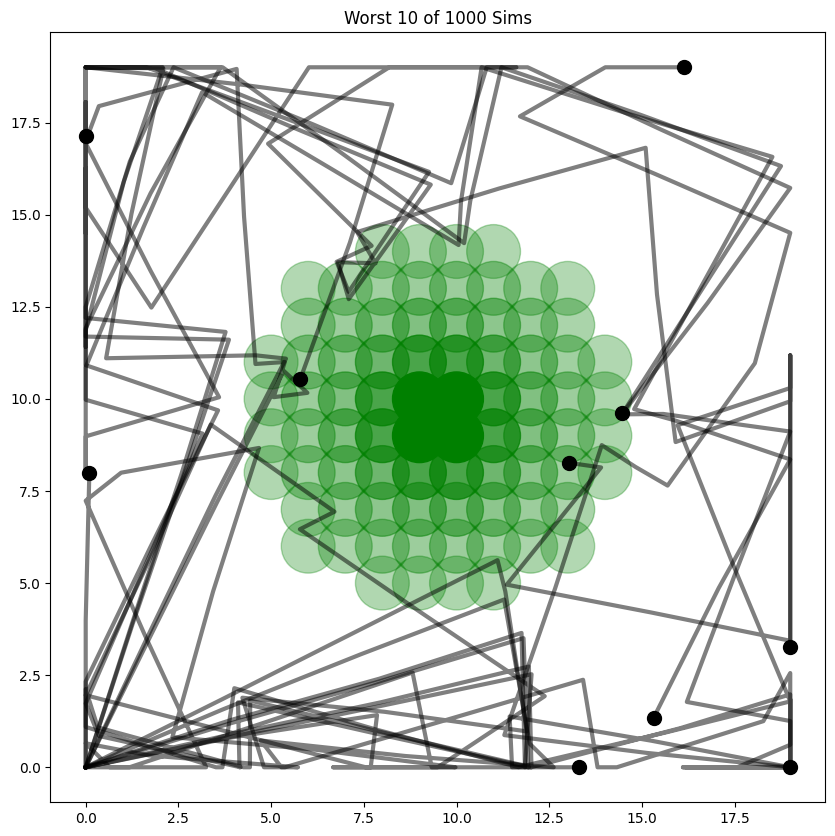

In [ ]:
#Run 1000 times and sample worst 10
worst10 = [] #values in this saved as [[totalDist],[xVals],[yVals]]
for run in range(1000):
  xRun, yRun = simulate(alpha, gamma, 19, 19, 30, steep)
  totDist = 0
  for step in range(len(xRun)):
    totDist += math.sqrt((xRun[step]-9.5)**2+(yRun[step]-9.5)**2)
  if(len(worst10)<10):
    worst10.append([totDist, xRun, yRun])
  else:
    inWorst = False
    for runs in range(len(worst10)):
      if(totDist>worst10[runs][0]):
        inWorst = True
    if(inWorst):
      worst10[bestOfWorstIndex(worst10)] = [totDist, xRun, yRun]
print(worst10)

plt.figure(figsize=(4, 4))

xG, yG, grad, reward = defineScene(19,19,0.75)
plt.scatter(xG, yG, s = 1000, alpha = grad, color = 'green')

for worstRun in range(len(worst10)):
  plt.plot(worst10[worstRun][1], worst10[worstRun][2], linewidth = 1, color = 'black', alpha = 0.5)
  plt.scatter(worst10[worstRun][1][-1], worst10[worstRun][2][-1], s = 10, color = 'black')

plt.title("Worst 10 of 1000 Sims")